In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment setup successful!")

Environment setup successful!


# Business Analytics Case Study
## Understanding Customer Churn in a Telecommunications Company

**Analyst:** Tinotenda Chadzingwa

**Internship:** AnalystLab Africa – Week 5

**Project Type:** Business Analytics Case Study

**Dataset:** Telco Customer Churn Dataset

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook, Power BI

# 1. Introduction

Customer retention is one of the most important challenges faced by telecommunications companies. Acquiring new customers is generally more expensive than retaining existing ones, making customer churn a critical business issue.

This case study analyzes the Telco Customer Churn dataset to identify the factors that influence customer churn. The analysis aims to uncover meaningful patterns, generate actionable business insights, and provide evidence-based recommendations that can help improve customer retention and support strategic decision-making.

# 2. Business Context

The telecommunications industry is highly competitive, with customers able to switch service providers easily. Customer churn results in lost revenue, increased marketing costs, and reduced customer lifetime value.

Understanding why customers leave enables organizations to develop targeted retention strategies, improve customer satisfaction, and strengthen long-term profitability.

This project approaches the problem from a business analytics perspective by using historical customer data to identify churn drivers and recommend practical business solutions.

# 3. Business Problem Statement

The telecommunications company is experiencing customer churn, leading to revenue loss and increased customer acquisition costs. Management seeks to understand the factors influencing customer churn so that effective retention strategies can be developed.

This analysis aims to identify the characteristics of customers who are most likely to churn and provide data-driven recommendations to reduce customer attrition.

# 4. Business Objectives

The objectives of this project are to:

- Understand customer churn patterns.
- Identify the factors that contribute most to customer churn.
- Explore relationships between customer demographics, services, billing information, and churn.
- Generate meaningful business insights from the analysis.
- Provide practical recommendations to improve customer retention.

# 5. Business Questions

This analysis seeks to answer the following questions:

- What percentage of customers have churned?
- Which customer groups are most likely to leave?
- Does contract type influence customer churn?
- Does customer tenure affect churn?
- Are higher monthly charges associated with increased churn?
- Which internet service has the highest churn?
- Does technical support reduce customer churn?
- Which payment methods are associated with higher churn?
- What recommendations can help reduce customer churn?

# 6. Project Workflow

The project will follow these stages:

1. Data Understanding
2. Data Cleaning and Preparation
3. Exploratory Data Analysis (EDA)
4. Identification of Key Drivers of Churn
5. Business Insights
6. Business Recommendations
7. Dashboard Development
8. Report and Presentation

# 7. Analytical Approach

The analysis will be guided by business hypotheses that will be tested using data exploration and visualization.

Examples of hypotheses include:

- Customers with month-to-month contracts may have a higher likelihood of churn.
- Customers with shorter tenure may be more likely to leave.
- Higher monthly charges may contribute to increased churn.
- Customers without additional support services may have higher churn rates.
- Payment methods may influence customer retention behavior.

These hypotheses will be evaluated using statistical summaries and visualizations to identify the factors most associated with customer churn.

In [9]:
import os

In [10]:
os.listdir()

['.ipynb_checkpoints', 'Untitled.ipynb', 'Week5_Business_Analytics.ipynb']

In [11]:
os.listdir()

['.ipynb_checkpoints',
 'Telco_Customer_Churn.csv.csv',
 'Untitled.ipynb',
 'Week5_Business_Analytics.ipynb']

In [17]:
#load the online retail dataset
df_Telco = pd.read_csv("Telco_Customer_Churn.csv.csv", encoding="latin1")

In [18]:
#Display the first 5 rows
print(df_Telco.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [19]:
# Check the number of rows and columns

df_Telco.shape

(7043, 21)

### Dataset Overview

The Telco Customer Churn dataset contains 7,043 customer records and 21 variables. The dataset includes information about customer demographics, subscribed services, account details, billing information, and churn status. Each row represents an individual customer, while each column represents a customer-related attribute.

In [20]:
# Display column names

df_Telco.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [21]:
# Display dataset information

df_Telco.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Initial Data Quality Findings

The dataset contains 7,043 customer records and 21 variables. The initial assessment using df.info() showed no standard missing values. However, further data quality checks will be performed to identify hidden missing values or formatting issues. Most variables are categorical, representing customer demographics, services, and account details.

One data quality issue was identified: the `TotalCharges` variable is stored as a string rather than a numerical value. This requires conversion during the data preparation stage before performing numerical analysis.

In [22]:
# Summary statistics for numerical variables

df_Telco.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Initial Statistical Observations

The numerical summary shows that customers have an average tenure of approximately 32 months, with customer relationships ranging from new customers to those who have remained for 72 months.

Monthly charges vary considerably, with customers paying between approximately $18 and $119 per month. This variation provides an opportunity to investigate whether pricing influences customer churn.

Approximately 16% of customers are senior citizens, allowing further analysis of whether age-related factors influence retention.

In [23]:
# Number of unique values in each column

df_Telco.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

## Categorical Variable Assessment

The dataset contains a combination of binary and multi-category variables representing customer demographics, subscribed services, account information, and billing preferences.

The target variable, Churn, contains two categories (Yes/No), making it suitable for customer retention analysis.

The customerID variable contains unique identifiers and will not be used as a predictive feature. The TotalCharges variable requires further data cleaning because it is stored as text instead of a numerical format.

In [24]:
# Check missing values

df_Telco.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Missing Value Assessment

The missing value assessment using pandas showed that all columns contain 7,043 non-null records, indicating that no standard missing values were present in the dataset.

However, additional checks will be performed during the data cleaning stage to identify hidden missing values or formatting issues, particularly within the TotalCharges variable, which is currently stored as a text field.

In [25]:
# Check for blank spaces in the dataset

(df_Telco == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## Hidden Missing Value Findings

Although the initial missing value assessment showed no missing values, further investigation identified 11 blank entries within the TotalCharges variable.

These values were stored as empty spaces rather than standard missing values. Since TotalCharges is a financial variable, these records require cleaning before performing numerical analysis.

In [26]:
# Check for duplicate rows

df_Telco.duplicated().sum()

np.int64(0)

## Duplicate Records Assessment

A duplicate record check was performed to identify repeated customer entries.

The analysis found **0 duplicate records**, indicating that each customer entry in the dataset is unique. Therefore, no duplicate removal was required.

# Phase 2 Summary: Data Understanding

The initial assessment provided an overview of the Telco Customer Churn dataset, which contains 7,043 customer records and 21 variables.

The dataset includes customer demographics, subscribed services, account details, billing information, and churn status.

Data quality checks identified no duplicate records and no standard missing values. However, further investigation revealed 11 blank entries in the TotalCharges variable, which requires conversion from text to numerical format during the data cleaning stage.

The findings from this phase will guide the preparation of the dataset for exploratory analysis and business insight generation.

In [27]:
# Create a copy of the Telco dataset for cleaning

df_clean = df_Telco.copy()

# Display first 5 rows

df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
# Check data types before cleaning

df_clean.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [29]:
# Convert TotalCharges to numeric

df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

# Verify the data type

df_clean["TotalCharges"].dtype

dtype('float64')

In [30]:
# Check missing values after converting TotalCharges

df_clean.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [31]:
# Remove rows with missing TotalCharges

df_clean = df_clean.dropna(subset=["TotalCharges"])

# Check the dataset size after cleaning

df_clean.shape

(7032, 21)

In [32]:
# Check for missing values after cleaning

df_clean.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [34]:
# Save the cleaned dataset

df_clean.to_csv("Telco_Customer_Churn_Cleaned.csv.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Phase 3: Data Cleaning Summary

The data cleaning process focused on improving data quality while preserving the integrity of the dataset.

### Cleaning Activities Performed

- Created a copy of the original dataset for cleaning.
- Converted the `TotalCharges` column from text to a numerical data type.
- Identified 11 hidden missing values that were originally stored as blank spaces.
- Removed the 11 records with missing `TotalCharges` values.
- Verified that no duplicate records existed.
- Saved the cleaned dataset for further analysis and dashboard development.

### Final Dataset

- Original records: **7,043**
- Records removed: **11**
- Final records: **7,032**
- Total variables: **21**

The cleaned dataset is now suitable for exploratory data analysis, visualization, dashboard creation, and business insight generation.

# Phase 4: Exploratory Data Analysis (EDA)

## Analysis 1: Overall Customer Churn Rate

### Business Question

What proportion of customers have churned, and what proportion have remained with the company?

Understanding the overall churn rate provides a baseline measure of customer retention performance and helps assess the scale of the business problem.

In [36]:
# Count customers by churn status

churn_counts = df_clean["Churn"].value_counts()

print(churn_counts)

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [37]:
# Calculate churn percentages

churn_percentage = (
    df_clean["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


### Interpretation

The analysis shows that 26.58% of customers have churned, while 73.42% have remained with the company.

Although the majority of customers are retained, more than one-quarter have discontinued their services. This represents a substantial loss of customers and highlights the need to identify the factors driving churn so that effective retention strategies can be implemented.

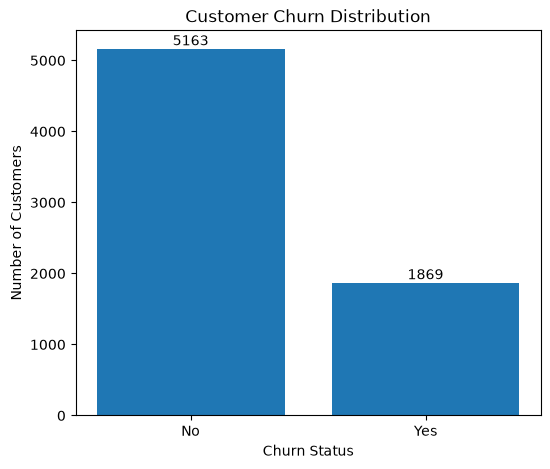

In [38]:
# Import matplotlib
import matplotlib.pyplot as plt

# Count churn categories
churn_counts = df_clean["Churn"].value_counts()

# Create figure
plt.figure(figsize=(6,5))

# Plot bar chart
plt.bar(churn_counts.index, churn_counts.values)

# Add title and labels
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

# Display values on top of each bar
for i, value in enumerate(churn_counts.values):
    plt.text(i, value + 50, str(value), ha='center')

plt.show()

### Business Insight

The company retains the majority of its customers; however, the churn rate of 26.58% indicates a significant customer retention challenge. Reducing churn by even a small percentage could have a positive impact on revenue and customer lifetime value.

Further analysis is required to determine which customer characteristics and service factors contribute most to customer churn.

## Analysis 2: Contract Type vs Customer Churn

### Business Question

Does the type of customer contract influence the likelihood of customer churn?

Contract type reflects the level of customer commitment. Customers with shorter contracts may be more likely to leave than those with longer-term agreements. This analysis investigates whether contract type is associated with customer churn.

In [39]:
# Contract Type vs Churn

contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"]
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [40]:
# Percentage of churn within each contract type

contract_churn_percentage = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

contract_churn_percentage.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


### Business Insight

Contract type is strongly associated with customer churn.

Customers with month-to-month contracts experience the highest churn rate at 42.71%, while customers on two-year contracts have the lowest churn rate at 2.85%.

This suggests that longer-term contracts improve customer retention by increasing customer commitment. The company should consider strategies that encourage month-to-month customers to transition into longer contract plans.

# Analysis 2: Customer Tenure vs Customer Churn

## Business Question

Does customer tenure influence the likelihood of customer churn?

Understanding the relationship between customer tenure and churn helps identify whether newer or long-term customers are more likely to leave the company. This can help the business develop targeted retention strategies.

In [41]:
# Calculate average tenure by churn status

df_clean.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

<Figure size 700x500 with 0 Axes>

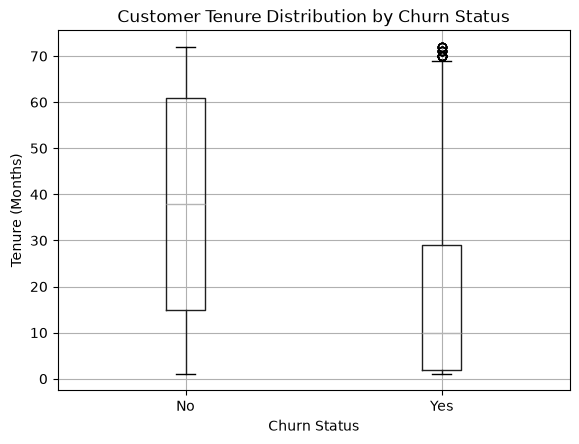

In [42]:
# Visualize tenure distribution by churn status

plt.figure(figsize=(7,5))

df_clean.boxplot(
    column="tenure",
    by="Churn"
)

plt.title("Customer Tenure Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.show()

## Business Insight

The tenure analysis shows that customers who churn generally have shorter relationships with the company compared to customers who remain.

Retained customers have a higher median tenure, while churned customers are concentrated within the earlier months of the customer lifecycle. This suggests that improving early customer experience, onboarding, and engagement strategies may help reduce churn.

## Analysis 3: Monthly Charges vs Customer Churn

### Business Question

Do customers with higher monthly charges have a higher likelihood of churning?

This analysis examines whether monthly charges influence customer churn behavior.

In [45]:
df_clean.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

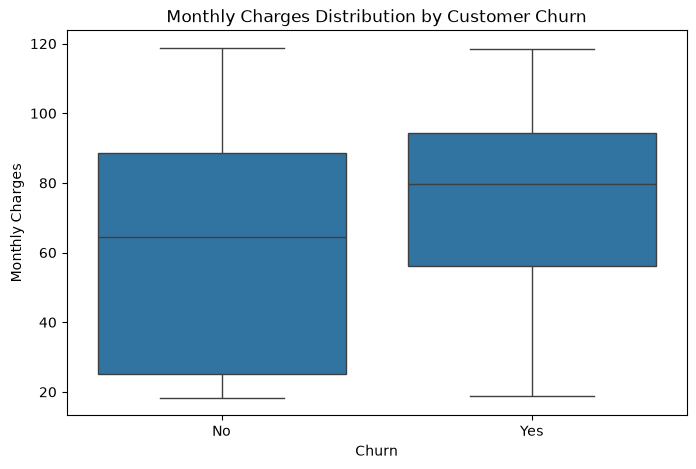

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df_clean
)

plt.title('Monthly Charges Distribution by Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

### Insight

Customers who churned have a higher average monthly charge (74.44) compared to customers who stayed (61.31). This suggests that customers paying higher monthly charges may have a higher likelihood of churning, possibly due to pricing concerns or perceived value.

## Analysis 4: Contract Type vs Customer Churn

### Business Question

Does contract type influence the likelihood of customers churning?

This analysis examines whether customers on different contract types have different churn patterns.

In [48]:
pd.crosstab(df_clean['Contract'], df_clean['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


### Insight

Customers with month-to-month contracts have the highest number of churned customers (1,655) compared to one-year (166) and two-year contracts (48). This suggests that customers with shorter contracts are more likely to churn, while longer-term contracts are associated with higher customer retention.

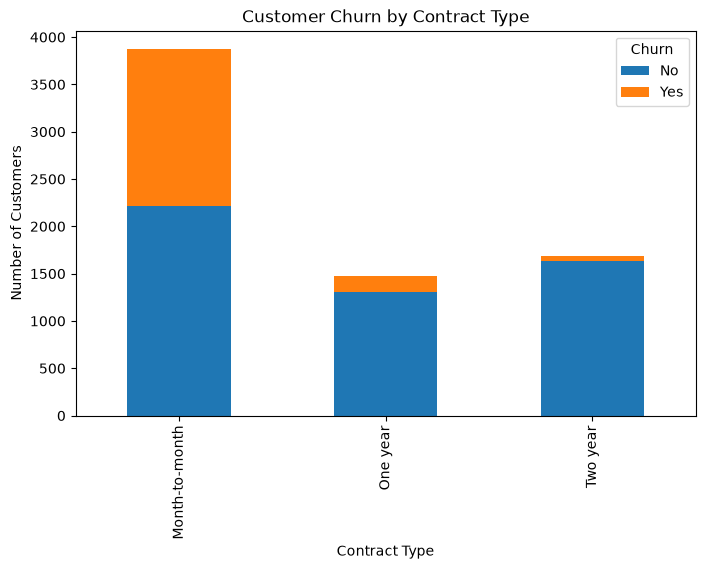

In [49]:
pd.crosstab(df_clean['Contract'], df_clean['Churn']).plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

## Analysis 5: Payment Method vs Customer Churn

### Business Question

Does payment method influence the likelihood of customers churning?

This analysis examines whether customers using different payment methods show different churn patterns.

In [50]:
pd.crosstab(df_clean['PaymentMethod'], df_clean['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


### Insight

Customers using electronic check have the highest number of churned customers (1,071) compared to other payment methods. Customers using automatic payment methods, such as bank transfer and credit card, show lower churn levels. This suggests that payment method may influence customer retention, with automatic payment methods being associated with lower churn.

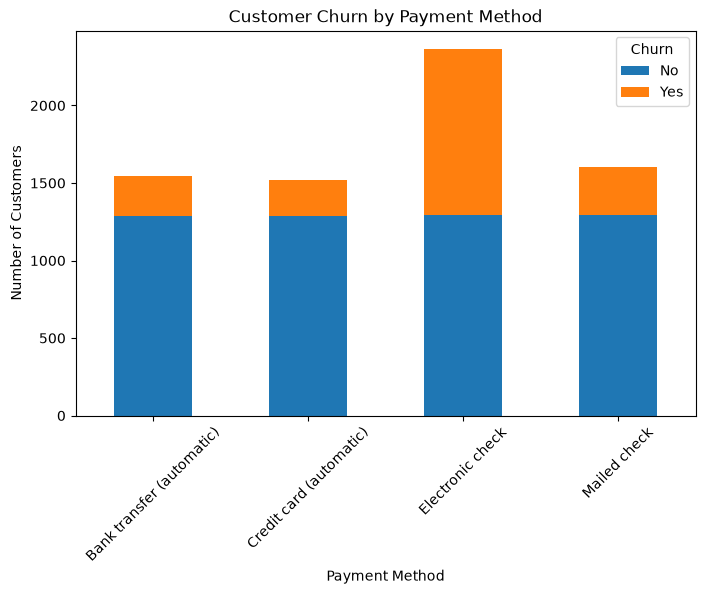

In [51]:
pd.crosstab(df_clean['PaymentMethod'], df_clean['Churn']).plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Customer Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.xticks(rotation=45)
plt.show()

## Key Findings and Insights

### 1. Customer Tenure vs Churn
Customers who churned had a lower average tenure compared to customers who stayed. This indicates that newer customers are more likely to leave the service.

### 2. Monthly Charges vs Churn
Customers who churned had higher average monthly charges compared to customers who stayed. This suggests that higher costs may contribute to customer dissatisfaction.

### 3. Contract Type vs Churn
Month-to-month contract customers showed the highest churn levels, while customers with longer contracts had lower churn rates. Longer contracts appear to improve customer retention.

### 4. Payment Method vs Churn
Customers using electronic check payments had the highest churn numbers, while customers using automatic payment methods showed lower churn levels.

## Business Recommendations

Based on the analysis findings, the following actions can help reduce customer churn:

1. **Improve retention of new customers**
   - Introduce onboarding programs, customer support follow-ups, and early engagement strategies for new customers.

2. **Review pricing and value offered**
   - Investigate why customers with higher monthly charges are more likely to churn and consider offering better value packages or discounts.

3. **Encourage longer-term contracts**
   - Provide incentives for customers to move from month-to-month contracts to one-year or two-year plans.

4. **Promote automatic payment methods**
   - Encourage customers to use automatic payment options by highlighting their convenience and offering incentives where appropriate.

5. **Target high-risk customers**
   - Use churn prediction models to identify customers likely to leave and apply personalized retention strategies.